<a href="https://colab.research.google.com/github/vitorjensen/Python_para_Analise_de_Dados/blob/main/Projetos/An%C3%A1lise%20Explorat%C3%B3ria%20de%20Combust%C3%ADvel/An%C3%A1lise_Explorat%C3%B3ria_de_Combust%C3%ADvel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importando bibliotecas necessárias:

In [1]:
import yfinance as yf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

In [ ]:
# pip install yfinance pandas

**Objetivo:** Fazer uma análise exploratória do Brent (Petróleo bruto) no período de 03/01/2022 a 27/09/2026

**Primeira parte:** Extração da base de dados utilizando o Yahoo Finance.

In [ ]:
# Definindo o ticker (Brent) a ser manipulado
ticker = "BZ=F"

# Criando o dataset com o período de dados estabelecido
data_inicio = "2022-01-01"
data_fim = datetime.now().strftime('%Y-%m-%d')

# Definindo um objeto para o ticker
brent = yf.Ticker(ticker)

# Criando o dataframe com os dados do Yahoo extraídos
df_brent = brent.history(start=data_inicio, end=data_fim)

display(df_brent.head())

In [ ]:
# Fazendo download em CSV da base para a máquina

df_brent = df_brent.to_csv('dados_brent.csv')

**Segunda parte:** Tratamento.

- Remover colunas indesejadas
- Verificar Total de linhas e colunas
- Renomear colunas
- Verificar ocorrências de valores 0
- Verificar valores duplicados
- Total de valores ausentes
- Verificação do tipo da coluna "Data"
- Verificando Data Início e Data Final
- Verificando Datas Únicas
- Verificando existência de Datas Duplicadas

In [ ]:
# Lendo aquivo CSV
df = pd.read_csv('/content/drive/MyDrive/dados_brent.csv')

# Total de colunas e linhas
display(df)

In [ ]:
# informações gerais do dataset

df.info()

In [ ]:
# Excluindo colunas indesejadas:
colunas_indesejadas = ['Dividends', 'Stock Splits']
df = df.drop(colunas_indesejadas, axis=1, errors='ignore')

display(df)

In [ ]:
# Total de linhas e colunas
print(f'Total de linhas: {df.shape[0]}')
print(f'Total de colunas: {df.shape[1]}')

Total de linhas: 1190
Total de colunas: 6


In [ ]:
# Renomear colunas
df = df.rename(columns={
    'Date': 'Data',
    'Open': 'Valor_Abertura',
    'Low': 'Valor_Minimo',
    'High': 'Valor_Maximo',
    'Close': 'Fechamento'
})

display(df)

In [ ]:
# Verificando existência de valores "zero"

geral_zeros = df[(df == 0).any(axis=1)]
print(f"Quantidade de linhas contendo pelo menos um zero: {len(geral_zeros)}")
display(geral_zeros)

In [ ]:
# Verificando total de duplicados

duplicados = df.duplicated().sum()
print(f'Total de valores duplicados: {duplicados}')

Total de valores duplicados: 0


In [ ]:
# Verificar valores ausentes
print("Valores ausentes por coluna:")
display(df.isnull().sum())

In [ ]:
# Verificando e garantindo o tipo da coluna data
df['Data'] = pd.to_datetime(df['Data'], errors='coerce', utc=True)

print(df['Data'].dtype)

datetime64[ns, UTC]


In [ ]:
# Verificando Data Inicial e Data Final

print(f"Data Inicial: {df['Data'].min()}")
print(f"Data Final: {df['Data'].max()}")


Data Inicial: 2022-01-03 05:00:00+00:00
Data Final: 2026-09-25 04:00:00+00:00


In [ ]:
# Verificando datas únicas

print(f"Total de data únicas: {df['Data'].nunique()}")

Total de data únicas: 1190


In [ ]:
# Verificando datas duplicadas

datas_duplicadas = df['Data'].duplicated().sum()
print(f"Quantidade de datas duplicadas: {datas_duplicadas}")

Quantidade de datas duplicadas: 0


In [ ]:
#Ordenando o dataset por data

df = df.sort_values('Data').reset_index(drop=True)
display(df.head())
display(df.tail())

Resultado do tratamento:

- Total de colunas removidas: 2 (Dividends e Stock Split)
- Total de linhas e colunas: 1190 x 6
- Total de colunas renomeadas: 5
- Total de ocorrências de valores 0: 8
- Total de valores duplicados: 0
- Total de valores ausentes: 0
- Verificação do tipo da coluna "Data" = OK
- Verificando Data Início e Data Final = OK
- Verificando Datas Únicas = OK
- Verificando existência de Datas Duplicadas = 0

**Terceira parte:** Análise Exploratória do Brent

- Execução do Describe (Variáveis Estatísticas).
- Verificação de Colunas categóricas.
- Verificação de Colunas numéricas.
- Visualização Estatística baseado nas Colunas Numéricas.
- Criação da coluna de Variação Percentual Diária.
- Analisando 10 dias com maiores **altas** e 10 dias com maiores **baixas**.
- Criação da Coluna Ano_Mes para análise mensal.
- Plotar gráfico para visualizar Evolução do Petróleo.
- Plotar gráfico para distribuição Preço.
- Plotar gráfico para visualização de Outliers.
- Plotar gráfico para Visualizar Volatilidade.
- Plotar Gráfico para Análise Mensal.
- Outras análises pertinentes ao conjunto de dados.

In [ ]:
# Verificando estatísticas básicas do Brent
df.describe()

In [ ]:
# Verificando colunas categóricas:

colunas_categoricas =[columns for columns in df.columns
                      if df[columns].dtype == 'object']

qtde_total = len(colunas_categoricas)

print(f'Qtde de colunas categóricas: {qtde_total}')

print(f'Colunas categóricas: {colunas_categoricas}')

In [ ]:
# Verificando colunas numéricas

colunas_numericas = [columns for columns in df.columns
                     if df[columns].dtype != 'object']

qtde_total = len(colunas_numericas)

print(f'Qtde de colunas numéricas: {qtde_total}')
print(f'Colunas numéricas: {colunas_numericas}')



Qtde de colunas numéricas: 6
Colunas numéricas: ['Data', 'Valor_Abertura', 'Valor_Maximo', 'Valor_Minimo', 'Fechamento', 'Volume']


In [ ]:
# Definindo as estatísticas baseada nas colunas numéricas

estatistica = df[colunas_numericas].describe().T
display(estatistica)

In [ ]:
# Definindo a Variação Diária em Porcentagem

df['Variacao_Diaria_%'] = df['Fechamento'].pct_change() * 100
display(df)

In [ ]:
# Analisando Variáveis estatísticas da Variação Diária

df['Variacao_Diaria_%'].describe()

In [ ]:
# Analisandos os 10 dias com Maiores Altas

maiores_altas = df.nlargest(10, 'Variacao_Diaria_%')
display(maiores_altas)

In [ ]:
#Analisando os 10 dias com Maiores Quedas

maiores_quedas = df.nsmallest(10, ['Variacao_Diaria_%'])
display(maiores_quedas)

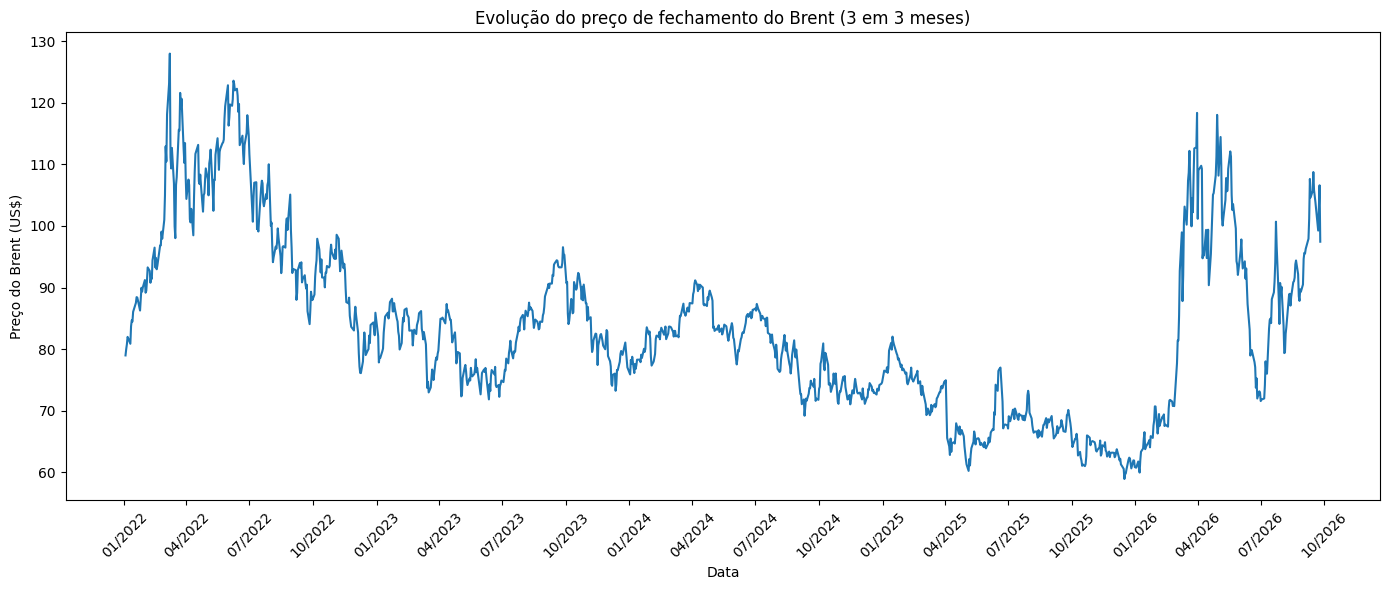

In [ ]:
# Plotando um gráfico para visualização da Evolução do Brent

plt.figure(figsize=(14, 6))
plt.plot(df['Data'], df['Fechamento'])
plt.title('Evolução do preço de fechamento do Brent (3 em 3 meses)')
plt.xlabel('Data')
plt.ylabel('Preço do Brent (US$)')
plt.gca().xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%m/%Y'))
plt.xticks(rotation=45)
plt.tight_layout()

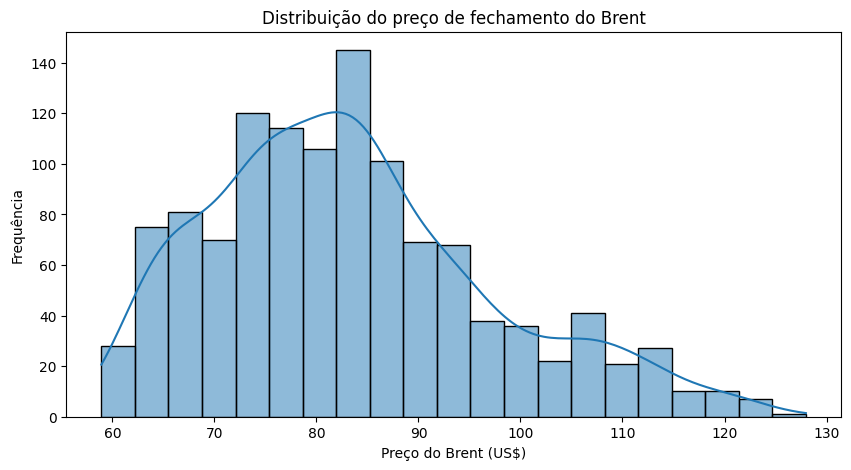

In [ ]:
# Plotando gráfico para visualizar a distribuição de preço

plt.figure(figsize=(10, 5))
sns.histplot(df['Fechamento'], kde=True)
plt.title('Distribuição do preço de fechamento do Brent')
plt.xlabel('Preço do Brent (US$)')
plt.ylabel('Frequência')

plt.show()

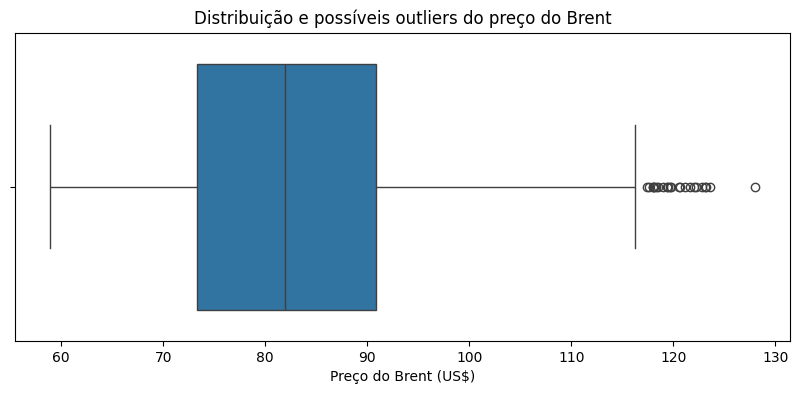

In [ ]:
# Plotando gráfico para verificar outliers de preços

plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Fechamento'])
plt.title('Distribuição e possíveis outliers do preço do Brent')
plt.xlabel('Preço do Brent (US$)')

plt.show()

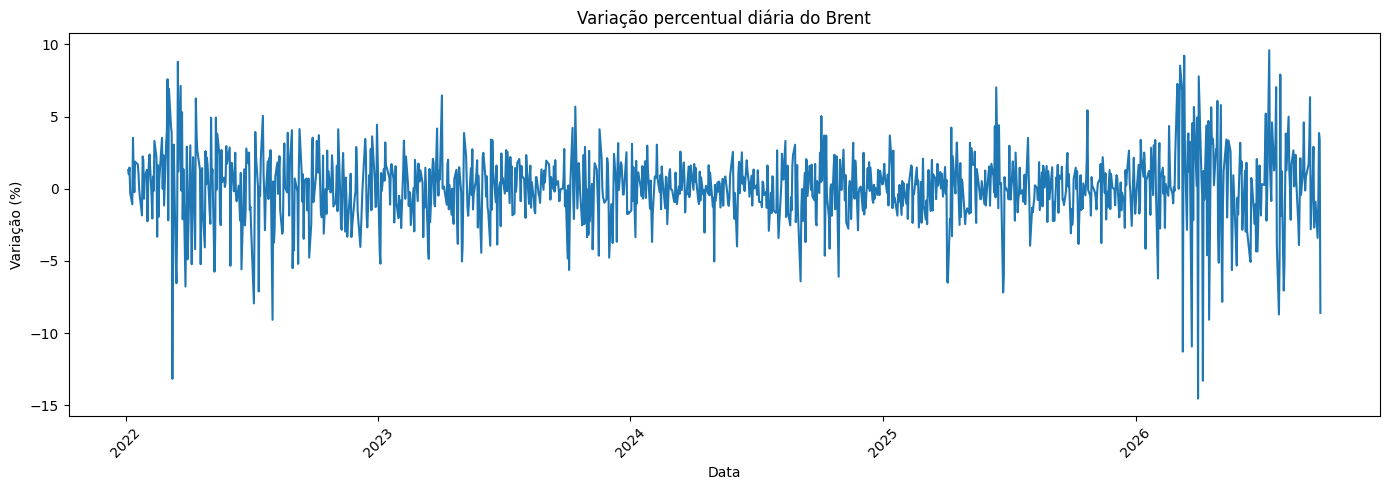

In [ ]:
# Plotando um gráfico da variação diária, verificando volatilidade.

plt.figure(figsize=(14, 5))
plt.plot(df['Data'], df['Variacao_Diaria_%'])
plt.title('Variação percentual diária do Brent')
plt.xlabel('Data')
plt.ylabel('Variação (%)')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Criando uma análise mensal

df['Ano_Mes'] = df['Data'].dt.to_period('M')
display(df)

In [ ]:
# Definindo colunas com funções de agregação por MÊS
brent_mensal = (
    df.groupby('Ano_Mes')
    .agg(
        Brent_Medio=('Fechamento', 'mean'),
        Brent_Minimo=('Valor_Minimo', 'min'),
        Brent_Maximo=('Valor_Maximo', 'max'),
        Brent_Desvio=('Fechamento', 'std')
    )
    .reset_index()
    )

In [ ]:
display(brent_mensal.head())

,Ano_Mes,Brent_Medio,Brent_Minimo,Brent_Maximo,Brent_Desvio
0,2022-01,85.527000,77.040001,91.690002,3.771236
1,2022-02,94.033685,87.720001,105.750000,3.271413
2,2022-03,112.463044,96.949997,137.000000,7.233524
3,2022-04,105.917000,97.620003,114.820000,3.669942
4,2022-05,111.497143,100.930000,124.129997,4.803067


In [ ]:
# Verificando a quantidade de meses analisados

print(f"Quantidade de meses analisados {len(brent_mensal)}")

Quantidade de meses analisados 57


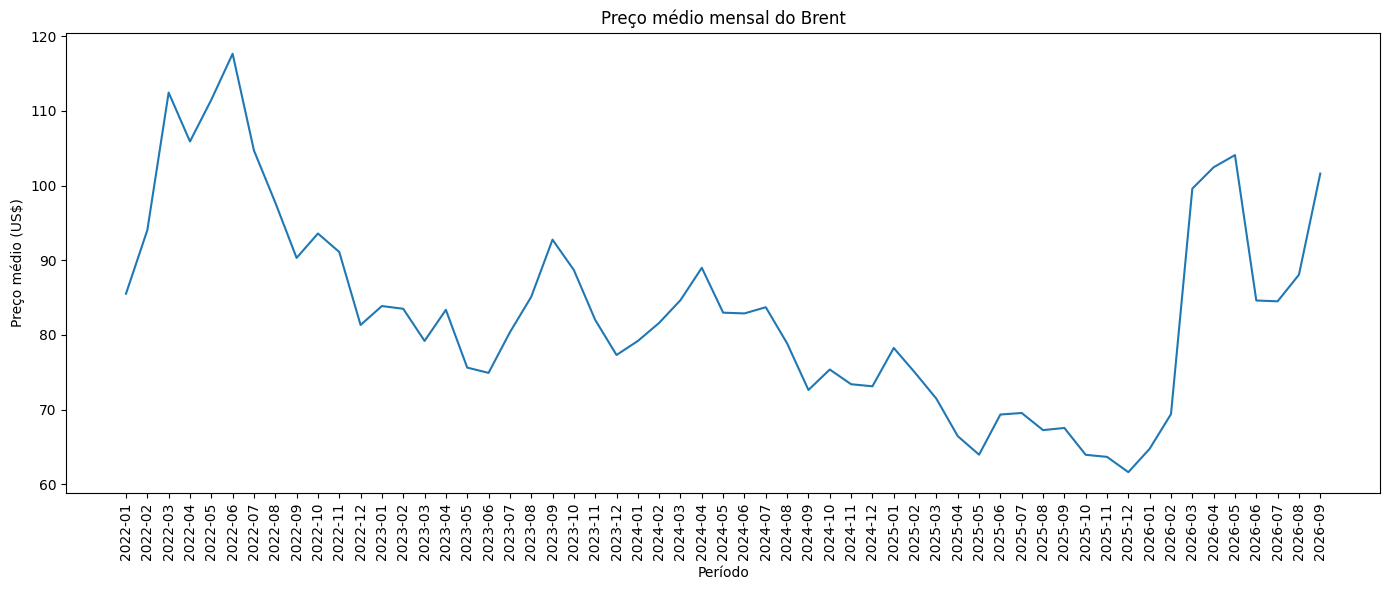

In [ ]:
# Plotando gráfico para análise mensal:

plt.figure(figsize=(14, 6))

plt.plot(
    brent_mensal['Ano_Mes'].astype(str),
    brent_mensal['Brent_Medio']
)

plt.title('Preço médio mensal do Brent')
plt.xlabel('Período')
plt.ylabel('Preço médio (US$)')

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

**Quarta Parte:** Análise Exploratória do combustível (ANP)

**Objetivo:** Fazer uma análise exploratória da Gasolina no período de 01/01/2022 a 01/08/2026

In [ ]:
# Importando e visualizando a base de dados:

df_anp = pd.read_csv('/content/drive/MyDrive/ANP_base_2022_2026.csv')

display(df_anp)

Etapas de Tratamento da base:

- Remover colunas indesejadas.
- Verificar Total de linhas e colunas.
- Verificar ocorrências de valores 0.
- Verificar valores duplicados.
- Total de valores nulos.
- Verificação do tipo da coluna "Data".
- Verificando Data Início e Data Final.
- Verificando Datas Únicas.
- Verificando existência de Datas Duplicadas.

In [3]:
# Removendo colunas indesejadas:

#df_anp.columnsdf_anp = df_anp.drop(['mes_data','ano','mes_num','regiao','postos_pesquisados', 'unidade_medida', 'margem_media_revenda', 'preco_medio_distribuicao', 'desvio_padrao_distribuicao', 'preco_minimo_distribuicao', 'preco_maximo_distribuicao', 'coef_variacao_distribuicao'], axis=1)

df_anp = df_anp.drop(['mes_data','ano','mes_num','regiao', 'unidade_medida', 'margem_media_revenda', 'preco_medio_distribuicao', 'desvio_padrao_distribuicao', 'preco_minimo_distribuicao', 'preco_maximo_distribuicao', 'coef_variacao_distribuicao'], axis=1)

In [ ]:
# Verificando Total de Linhas e Colunas

df_anp.info()

In [ ]:
# Verificando a ocorrência de valores 0

geral_zeros_anp = df_anp[(df_anp == 0).any(axis=1)]
display(geral_zeros_anp)

In [ ]:
# Verificando total de valores duplicados

geral_anp_duplicados = df_anp.duplicated()
display(geral_anp_duplicados)

In [ ]:
# Verificando total de valores nulos

geral_anp_nulos = df_anp.isnull()
display(geral_anp_nulos)

In [4]:
# Transformando a coluna mes_ano em datetime

df_anp['mes_ano'] = pd.to_datetime(df_anp['mes_ano'], errors='coerce', utc=True)
df_anp['mes_ano'].dtype

datetime64[ns, UTC]

In [ ]:
# Verificando Data Início e Data Final

print(f"Data inicial: {df_anp['mes_ano'].min()}")
print(f"Data final: {df_anp['mes_ano'].max()}")

In [ ]:
# Verificando quantidade de datas únicas
print(f"Quantidade de datas únicas: {df_anp['mes_ano'].nunique}") # O nunique fará um agrupamento

In [ ]:
# Verificando se há datas duplicadas
data_duplicada = df_anp['mes_ano'].duplicated() # O duplicated contará registro por registro sem agrupar
print(f"Soma de datas duplicadas:{data_duplicada}")

Etapa de análise exploratória da ANP:

- Filtrar apenas pela GASOLINA COMUM em Produto
- Execução do Describe (Estatística descritiva).
- Verificação de Colunas categóricas.
- Verificação de Colunas numéricas.
- Análise Univariada dos atributos numéricos.
- Verificando média de postos pesquisados agrupados por mês
- Plotando gráfico para visualizar evolução do preço do Combustível
- Verificar 10 meses de maior alta.
- Verificar 10 meses de maior baixa.
- Comparação entre estados
- Qualidade/Confiabilidade da amostra.
- Sazonalidade.
- Checks de qualidade (antes de fechar a EDA)

In [ ]:
# Exibindo o dataframe

display(df_anp)

In [ ]:
# Filtrando apenas a GASOLINA COMUM na coluna "Produto" do Dataframe.

df_anp = df_anp[df_anp['produto'] == 'GASOLINA COMUM'].reset_index(drop=True)
display(df_anp)

In [ ]:
# Aplicando análise descritiva no atributo preco_medio_revenda

analise_estatistica = df_anp['preco_medio_revenda'].describe()
display(analise_estatistica)

In [ ]:
# Verificando colunas categóricas:

colunas_categoricas = [columns for columns in df_anp.columns
                        if df_anp[columns].dtype == 'object']
qtde_categoricas = len(colunas_categoricas)
print(f"Quatidade de colunas categóricas: {qtde_categoricas} - {colunas_categoricas}")

Quatidade de colunas categóricas: 3 - ['mes_ano', 'produto', 'estado']


In [5]:
# Verificando colunas numéricas:
colunas_numericas = [columns for columns in df_anp.columns
                     if df_anp[columns].dtype != object ]

qtde_numericas = len(colunas_numericas)
print(f"Quatidade de colunas numéricas: {qtde_numericas} - {colunas_numericas}")

Quatidade de colunas numéricas: 7 - ['mes_ano', 'postos_pesquisados', 'preco_medio_revenda', 'desvio_padrao_revenda', 'preco_minimo_revenda', 'preco_maximo_revenda', 'coef_variacao_revenda']


In [ ]:
# Fazendo análise descritiva com Describe em colunas numéricas
estatisticas_descritivas = df_anp[colunas_numericas].describe().T
display(estatisticas_descritivas)

In [ ]:
# Verificando média de postos pesquisados por mês

anp_mensal = (
    df_anp.groupby('mes_ano').agg(
        Media_Postos=('postos_pesquisados', 'mean')
    ).reset_index()
)

In [ ]:
display(anp_mensal.head())

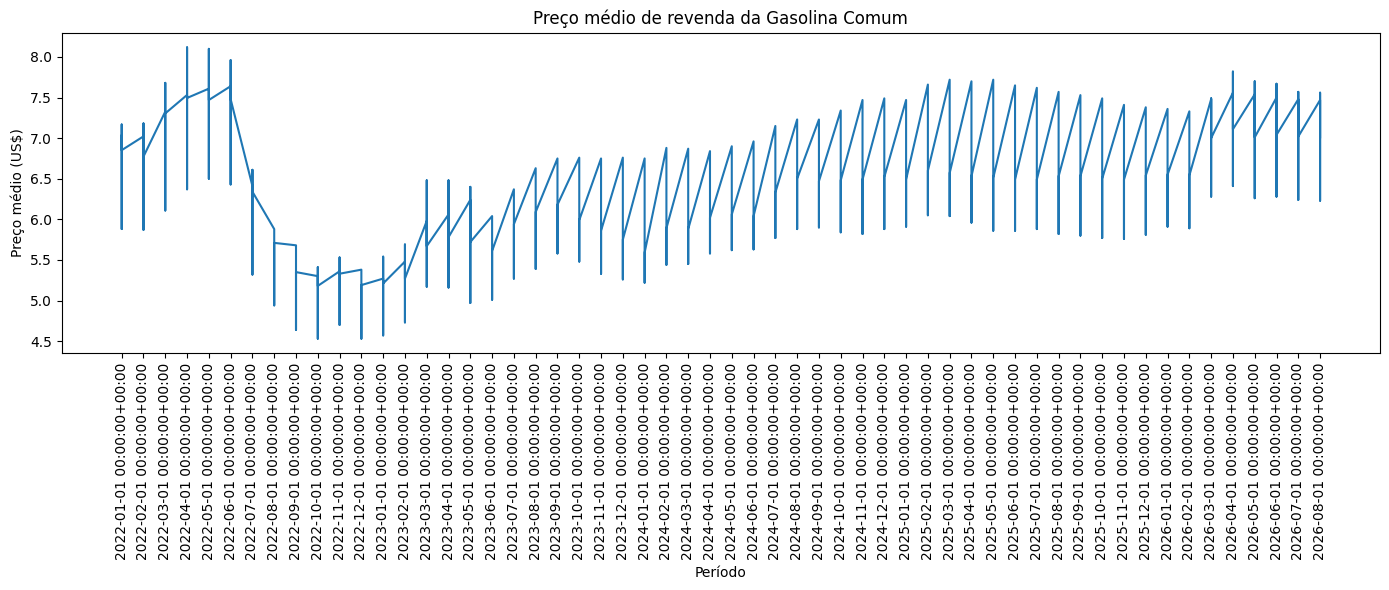

In [ ]:
# Plotando gráfico para análise mensal:

plt.figure(figsize=(14, 6)) # Estipulando o tamanho da janela
plt.plot(df_anp['mes_ano'].astype(str), df_anp['preco_medio_revenda']) # Definindo as variáveis que serão utilizadas para plotagem

plt.title('Preço médio de revenda da Gasolina Comum')
plt.xlabel('Período')
plt.ylabel('Preço médio (US$)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
# Verificando os 10 meses com maior variação de revenda

maiores_altas = df_anp.nlargest(10, 'coef_variacao_revenda')
display(maiores_altas)

In [ ]:
# Verificando os 10 meses com menor variação de revenda

menores_altas = df_anp.nsmallest(10, 'coef_variacao_revenda')
display(menores_altas)


/tmp/ipykernel_1681/2731860461.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='preco_medio_revenda', y='estado', data=preco_por_estado, palette='viridis')


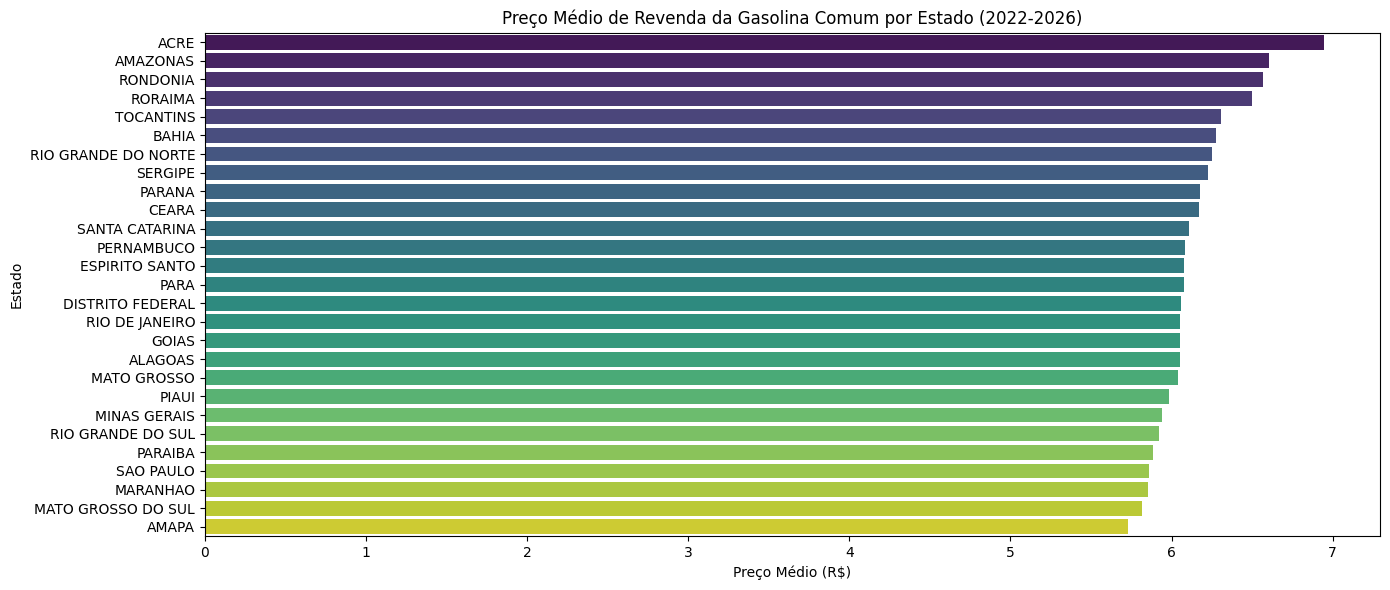

,estado,preco_medio_revenda
0,ACRE,6.946643
1,AMAZONAS,6.606732
2,RONDONIA,6.566286
3,RORAIMA,6.498589
4,TOCANTINS,6.310089
5,BAHIA,6.277821
6,RIO GRANDE DO NORTE,6.253036
7,SERGIPE,6.227732
8,PARANA,6.173821
9,CEARA,6.172018


In [19]:
# Análise de estados com maior preço médio de revenda

# Garantindo que a coluna 'mes_ano' seja do tipo datetime
df_anp['mes_ano'] = pd.to_datetime(df_anp['mes_ano'], errors='coerce')

# 1. Criando a coluna de ano extraindo do datetime 'mes_ano'
df_anp['ano'] = df_anp['mes_ano'].dt.year

# 2. Agrupando por estado para obter a média geral do preço de revenda
preco_por_estado = df_anp.groupby('estado')['preco_medio_revenda'].mean().sort_values(ascending=False).reset_index()

# Plotando o gráfico das maiores médias de revenda por estado (Geral)
plt.figure(figsize=(14, 6))
sns.barplot(x='preco_medio_revenda', y='estado', data=preco_por_estado, palette='viridis')
plt.title('Preço Médio de Revenda da Gasolina Comum por Estado (2022-2026)')
plt.xlabel('Preço Médio (R$)')
plt.ylabel('Estado')
plt.tight_layout()
plt.show()

# Exibindo os top 10 estados com maior preço médio
display(preco_por_estado.head(10))

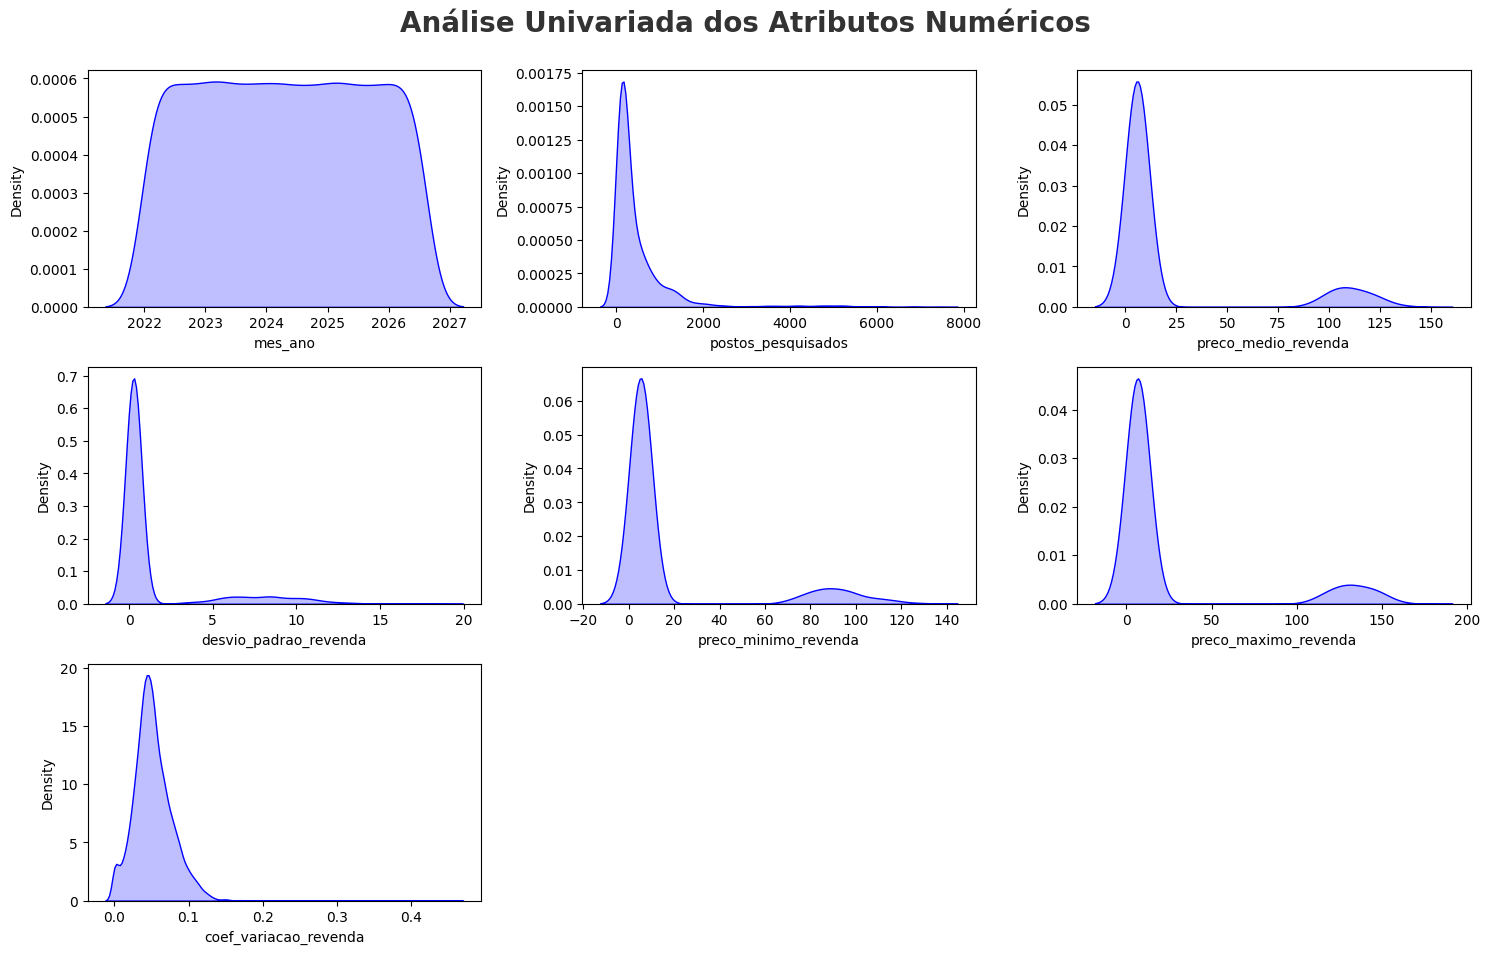

In [9]:
# Análise Univariada de Atributos Numéricos

# Definindo o tamanho da janela
plt.figure(figsize=(15,15))
plt.suptitle("Análise Univariada dos Atributos Numéricos", fontsize=20, fontweight='bold', alpha=0.8, y=1)


for i in range(len(colunas_numericas)):
  plt.subplot(5,3,i+1)
  sns.kdeplot(x=df_anp[colunas_numericas[i]],fill=True,color='b')
  plt.xlabel(colunas_numericas[i])
  plt.tight_layout()
